# Flipkart Product Price Analysis

**Dataset**: [Flipkart Products](https://www.kaggle.com/datasets/PromptCloudHQ/flipkart-products) (Kaggle)
**Difficulty**: Intermediate | **Est. time**: 2-3 weeks

Second project in the [data-analysts-projects-101](../README.md) series. This one leans harder on
SQL than project 1: percentiles, window functions, and CASE-based tiering over a 20,000-row Flipkart
product catalog.

**Architecture note**: as with every project in this repo, the analysis lives in
[`queries.sql`](./queries.sql) as named DuckDB queries, [`db.py`](./db.py) loads the data and runs
them, and this notebook + `app.py` both call the same named queries — no duplicated SQL.

Run `python download_data.py` once first to pull the dataset into `data/`.


In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import db

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

con = db.get_connection()


## 1. Dataset overview

20,000 product listings scraped from Flipkart in 2016. Key columns: `retail_price` (list price),
`discounted_price` (actual selling price), `product_category_tree` (a nested category string), and
`product_rating` (mostly missing — worth checking exactly how missing before relying on it).


In [2]:
products = con.execute("SELECT * FROM products").df()
print(f"{len(products):,} products, {products.shape[1]} columns\n")
products[["retail_price", "discounted_price", "product_rating", "brand"]].info()


20,000 products, 15 columns

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   retail_price      19922 non-null  Int64
 1   discounted_price  19922 non-null  Int64
 2   product_rating    20000 non-null  str  
 3   brand             14139 non-null  str  
dtypes: Int64(2), str(2)
memory usage: 1.1 MB


In [3]:
# product_rating is stored as text ("5", "4.5", or the literal string
# "No rating available") rather than a clean numeric column — a common
# real-world data quality issue. TRY_CAST in the SQL handles this by
# silently converting non-numeric values to NULL instead of erroring.
rated_pct = pd.to_numeric(products["product_rating"], errors="coerce").notna().mean()
print(f"Only {rated_pct:.1%} of listings have a numeric rating — any rating-based finding below "
      "should be read with that small-sample caveat in mind.")


Only 9.2% of listings have a numeric rating — any rating-based finding below should be read with that small-sample caveat in mind.


## 2. Category profitability

`product_category_tree` arrives as `'["Clothing >> Women\'s Clothing >> ... "]'` — a single string
encoding a full category path. Every query below pulls out just the top-level segment with
`TRIM(SPLIT_PART(TRIM(product_category_tree, '["]'), '>>', 1))`.


,category,product_count,avg_retail_price,avg_discounted_price,avg_discount_pct
0,Clothing,6171,1369.22,714.36,45.07
1,Jewellery,3522,7662.52,5558.82,40.89
2,Footwear,1225,1744.17,1077.31,36.27
3,Mobiles & Accessories,1097,1810.09,957.37,51.00
4,Automotive,1010,2903.33,1189.15,54.65
5,Home Decor & Festive Needs,927,2770.84,1835.76,36.65
6,Beauty and Personal Care,709,848.58,593.92,19.83
7,Home Furnishing,700,1941.93,1234.25,37.22
8,Kitchen & Dining,645,914.72,566.96,43.77
9,Computers,573,3236.08,2084.44,43.46


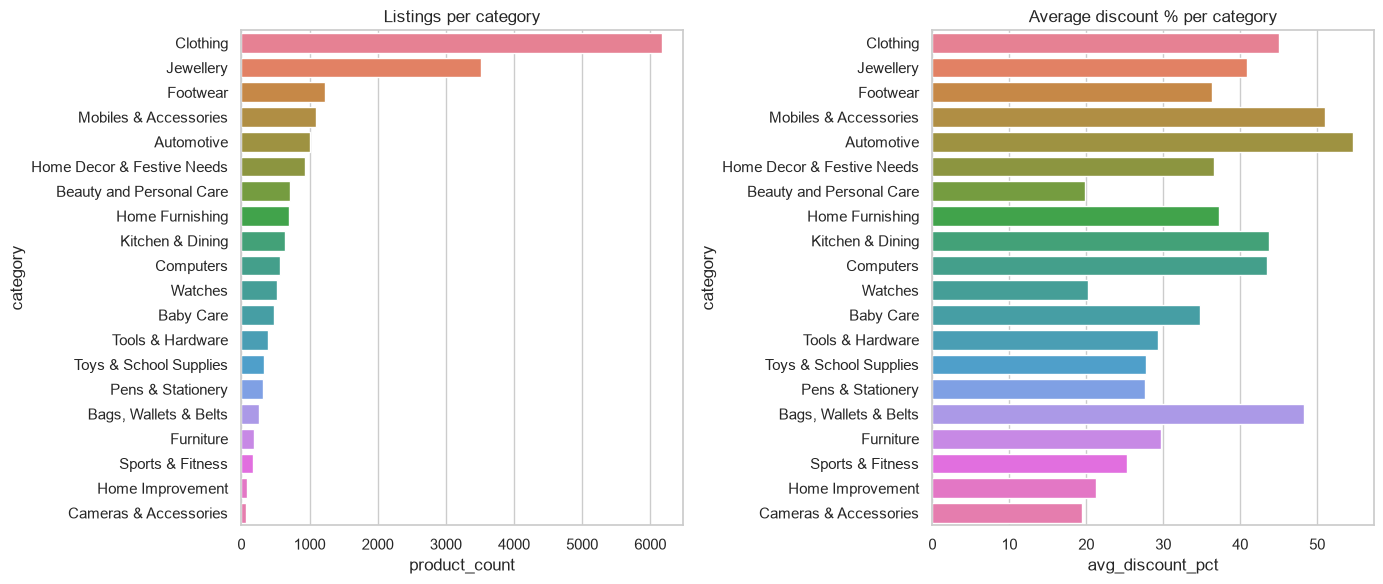

In [4]:
overview_df = db.run_query("category_overview", con)
display(overview_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(overview_df, x="product_count", y="category", hue="category", legend=False, ax=axes[0])
axes[0].set_title("Listings per category")
sns.barplot(overview_df, x="avg_discount_pct", y="category", hue="category", legend=False, ax=axes[1])
axes[1].set_title("Average discount % per category")
plt.tight_layout()
plt.show()


**Finding**: Clothing, Jewellery, and Footwear dominate the catalog by listing count. Discount
depth varies meaningfully by category — some categories are discounted much more aggressively than
others on average, which matters for a pricing/promotions strategy: uniform "20% off everything"
sales don't reflect how these categories are actually priced.


## 3. Price distribution (percentiles)

The doc's headline SQL concept for this project: `PERCENTILE_CONT()` for quartile-level price
distributions, restricted to categories with at least 50 listings so the percentiles mean something.


In [5]:
percentile_df = db.run_query("category_price_percentiles", con)
percentile_df


,category,product_count,avg_price,median_price,q1,q3,price_range
0,Clothing,6171,1369.22,999.0,799.0,1499.0,69850
1,Jewellery,3522,7662.52,999.0,599.0,2500.0,49874
2,Footwear,1225,1744.17,1599.0,999.0,2199.0,19826
3,Mobiles & Accessories,1097,1810.09,1999.0,999.0,2199.0,116142
4,Automotive,1010,2903.33,2800.0,1050.0,4900.0,44670
5,Home Decor & Festive Needs,927,2770.84,1299.0,749.0,2000.0,47421
6,Beauty and Personal Care,709,848.58,400.0,360.0,650.0,25414
7,Home Furnishing,700,1941.93,1530.0,799.0,2149.0,14649
8,Kitchen & Dining,645,914.72,650.0,499.0,920.0,34133
9,Computers,573,3236.08,2000.0,999.0,3999.0,38721


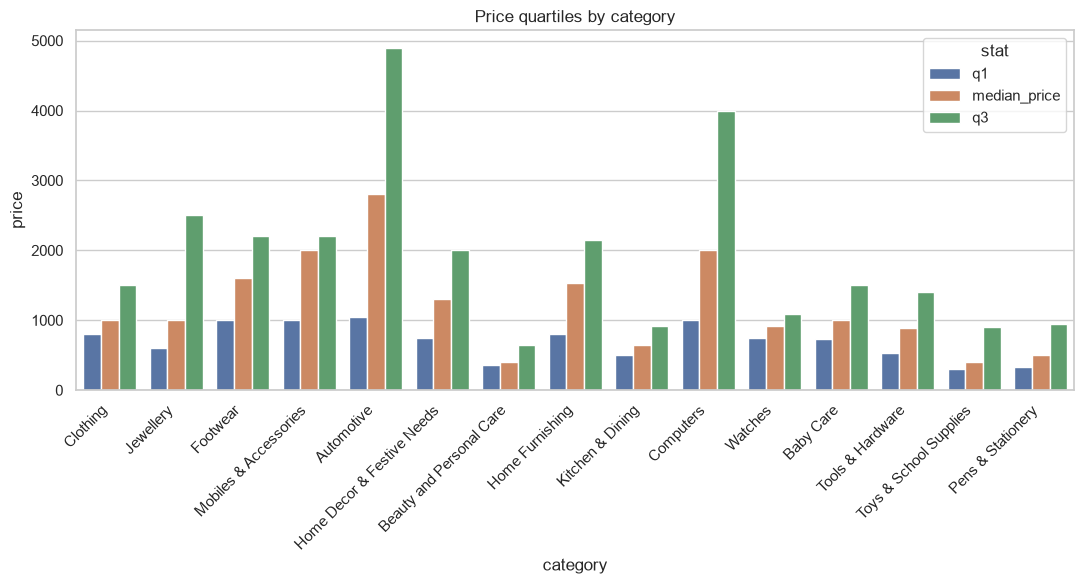

In [6]:
plot_df = percentile_df.melt(
    id_vars="category", value_vars=["q1", "median_price", "q3"],
    var_name="stat", value_name="price",
)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(plot_df, x="category", y="price", hue="stat", ax=ax)
ax.set_title("Price quartiles by category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4. Price tiering

A `CASE WHEN` bins every product into Budget / Mid / Premium / Luxury based on retail price — a
common first step before any pricing-strategy discussion ("how much of our catalog is actually
budget-tier?").


,price_tier,product_count,avg_retail_price,avg_discount_pct
0,1. Budget (<500),3140,381.62,27.48
1,2. Mid (500-2000),12128,1098.54,42.74
2,3. Premium (2000-10000),3737,3487.64,48.14
3,4. Luxury (10000+),917,34675.05,24.81


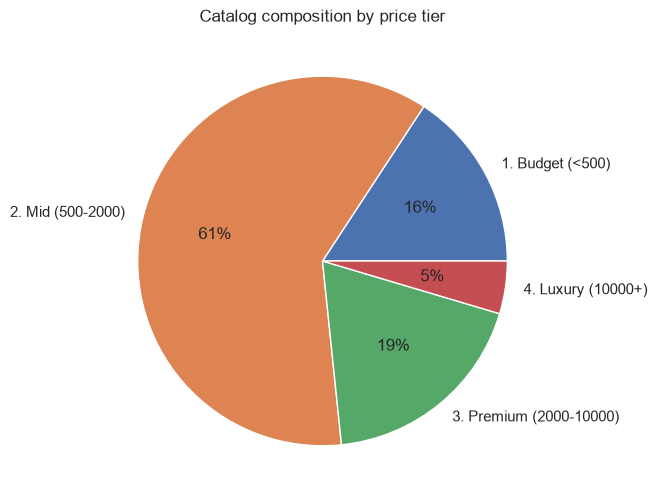

In [7]:
tier_df = db.run_query("price_tier_binning", con)
display(tier_df)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(tier_df["product_count"], labels=tier_df["price_tier"], autopct="%1.0f%%")
ax.set_title("Catalog composition by price tier")
plt.show()


## 5. Deepest discounts per category (window functions)

`RANK() OVER (PARTITION BY category ORDER BY discount_pct DESC)` finds the top-3 deepest discounts
*within each category* — something a plain `ORDER BY ... LIMIT` can't do per-group without a window
function.


In [8]:
top_discount_df = db.run_query("top_discounted_products", con)
top_discount_df.head(15)


,category,product_name,brand,retail_price,discounted_price,discount_pct
0,883 Police Full Sleeve Solid Men's Jacket,883 Police Full Sleeve Solid Men's Jacket,883 Police,7499,6374,15.0
1,"ABEEZ Boys, Men, Girls (Black, Pack of 1)","ABEEZ Boys, Men, Girls",ABEEZ,399,289,27.6
2,ANAND ARCHIES Girls Flats,ANAND ARCHIES Girls Flats,ANAND ARCHIES,499,399,20.0
3,ANAND ARCHIES Girls Flats,ANAND ARCHIES Girls Flats,ANAND ARCHIES,499,499,0.0
4,ANAND ARCHIES Girls Wedges,ANAND ARCHIES Girls Wedges,ANAND ARCHIES,899,899,0.0
5,ANASAZI Casual 3/4 Sleeve Solid Women's Top,ANASAZI Casual 3/4 Sleeve Solid Women's Top,ANASAZI,899,899,0.0
6,ATV Pouch for Acer Liquid Z330 (STEEL BLUE),ATV Pouch for Acer Liquid Z330,ATV,549,399,27.3
7,Abhinl Fashion Cotton Printed Semi-stitched Sa...,Abhinl Fashion Cotton Printed Semi-stitched Sa...,Abhinl Fashion,2599,999,61.6
8,"Adidas IND PRO THI GUA Thigh Guard (White, Blu...",Adidas IND PRO THI GUA Thigh Guard,Adidas,999,999,0.0
9,Ajaero Slim Fit Women's Dark Blue Jeans,Ajaero Slim Fit Women's Dark Blue Jeans,Ajaero,1699,679,60.0


## 6. Does discount depth correlate with rating?


In [9]:
corr_df = db.run_query("discount_vs_rating_correlation", con)
display(corr_df)


,discount_vs_rating_corr,rated_product_count
0,-0.002,1839


**Finding**: essentially zero correlation (r ≈ -0.002) between discount % and product rating. Heavy
discounting doesn't appear to buy better reviews — worth stating plainly, since it's tempting to
assume "more discount = happier customers" without checking. (Caveat: only ~9% of listings have a
rating at all, so this is directional, not conclusive.)


## 7. Price outliers

Products priced at 10x+ their category's median — either a data-entry error or a genuine
ultra-premium listing worth a second look.


In [10]:
outlier_df = db.run_query("price_outliers", con)
outlier_df.head(10)


,category,product_name,brand,retail_price,median_price,x_median
0,Watches,Breitling AB011010/BB08 131S Chronomat 44 Anal...,NaN,571230,917.5,622.6
1,Watches,"Cartier W6701005 Analog Watch - For Boys, Men",NaN,201000,917.5,219.1
2,Pens & Stationery,"NITGEN eNBioAccess T5-HID Time & Attendance, A...",NITGEN,71687,499.0,143.7
3,Watches,TAG Heuer CAU1116.BA0858 Formula 1 Analog Watc...,NaN,107750,917.5,117.4
4,Pens & Stationery,NITGEN Fingkey Access Plus-HID Time & Attendan...,NITGEN,58520,499.0,117.3
5,Furniture,Durian Leather 2 Seater Sofa,Durian,250500,3399.0,73.7
6,Clothing,The Curve Full Sleeve Solid Men's Quilted Jacket,NaN,69999,999.0,70.1
7,Furniture,Durian Laze/3 Leather 3 Seater Sofa,Durian,217500,3399.0,64.0
8,Beauty and Personal Care,HomeEdge Solid Wood King Bed,HomeEdge,25499,400.0,63.7
9,Furniture,Durian Leather 2 Seater Sofa,Durian,204600,3399.0,60.2


## Key takeaways

- Clothing, Jewellery, and Footwear are the highest-volume categories, but discount depth varies a
  lot by category — a flat storewide discount policy doesn't match how the catalog is actually priced.
- Discount percentage shows essentially no correlation with product rating (r ≈ -0.002) — deep
  discounting is not, by itself, a proxy for customer satisfaction in this data.
- A handful of listings sit at 10x+ their category's median price — worth a manual data-quality
  pass before trusting any category-level average that includes them.

## Next steps
```bash
streamlit run app.py
```
